In [15]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F

from PIL import Image
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [6]:
#Defining the dataset paths
TEST_DIR = "../datasets/test/rgb-front"

FOG_DIR = "../datasets/test-fog/rgb-front"

NIGHT_DIR = "../datasets/test-night/rgb-front"

TOWN_DIR = "../datasets/test-town-01/rgb-front"

RESULTS_DIR = "../results/excercise_7"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
class ImageOnlyDataset(Dataset):

    def __init__(self, image_dir, transform=None):

        self.image_dir = image_dir
        self.transform = transform

        self.images = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".jpg")
        ])

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [9]:
#9.4.1 Here we are creating three colums, one for fog, one for night and one for daytime/sunny
def create_distribution_shift_figure():

    sunny_imgs = random.sample(
        sorted(os.listdir(TEST_DIR)),
        5
    )

    fog_imgs = random.sample(
        sorted(os.listdir(FOG_DIR)),
        5
    )

    night_imgs = random.sample(
        sorted(os.listdir(NIGHT_DIR)),
        5
    )

    fig, axes = plt.subplots(
        5,
        3,
        figsize=(10, 15)
    )

    for row in range(5):

        img = Image.open(
            os.path.join(
                TEST_DIR,
                sunny_imgs[row]
            )
        )

        axes[row,0].imshow(img)
        axes[row,0].axis("off")

        img = Image.open(
            os.path.join(
                FOG_DIR,
                fog_imgs[row]
            )
        )

        axes[row,1].imshow(img)
        axes[row,1].axis("off")

        img = Image.open(
            os.path.join(
                NIGHT_DIR,
                night_imgs[row]
            )
        )

        axes[row,2].imshow(img)
        axes[row,2].axis("off")

    axes[0,0].set_title("Sunny / Daytime")
    axes[0,1].set_title("Fog")
    axes[0,2].set_title("Night")

    plt.tight_layout()

    output_path = os.path.join(
        RESULTS_DIR,
        "distribution_shift.png"
    )

    plt.savefig(
        output_path,
        bbox_inches="tight"
    )

    plt.show()

    print(output_path)

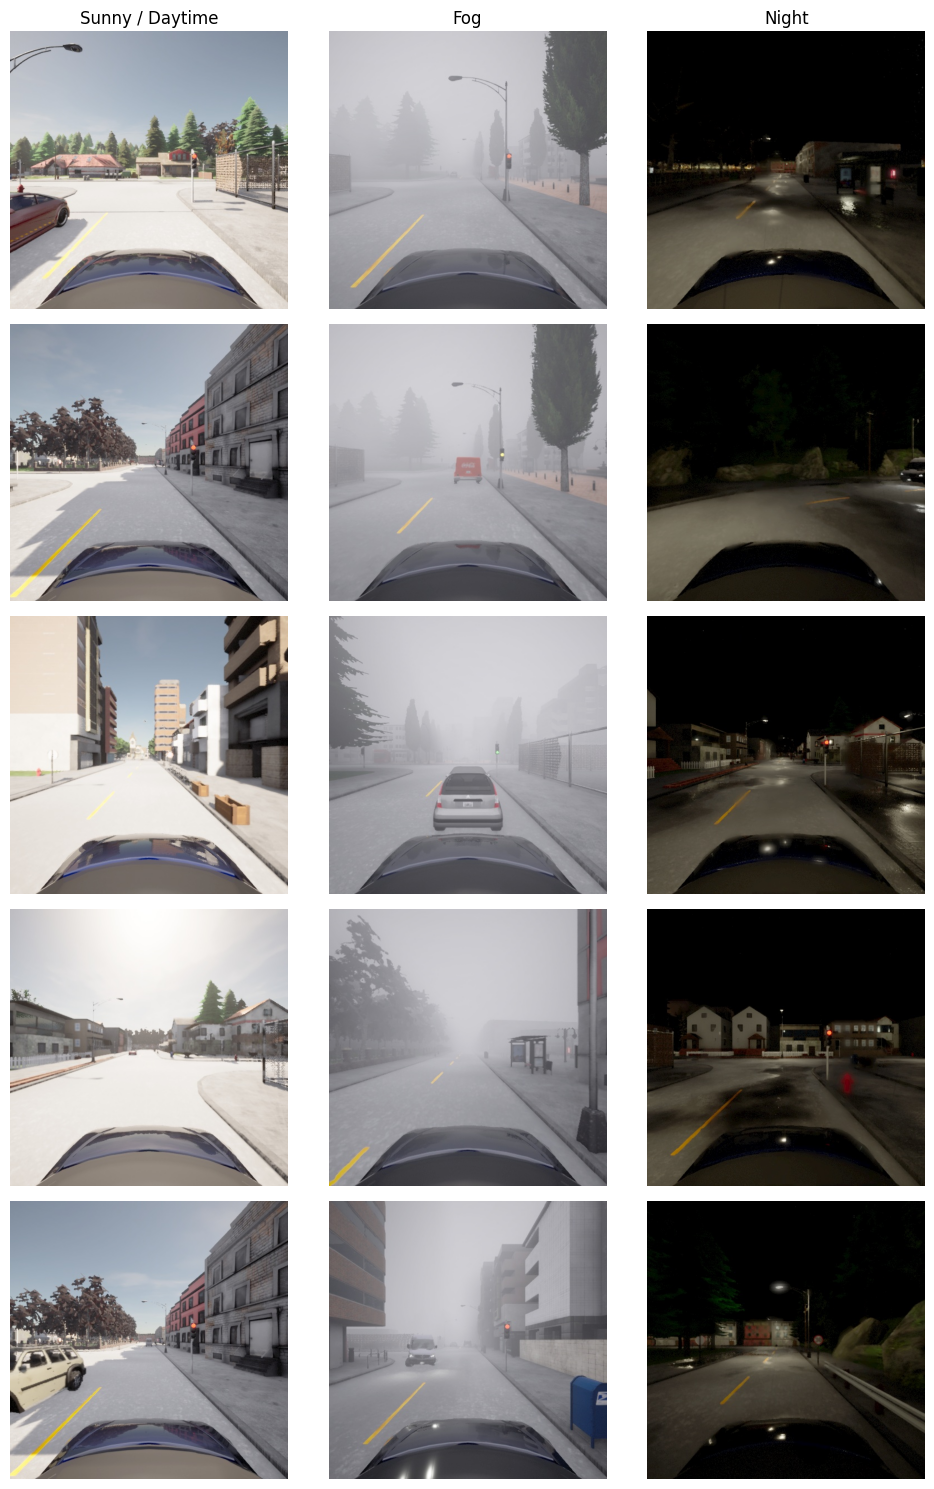

../results/excercise_7\distribution_shift.png


In [10]:
#image creation
create_distribution_shift_figure()

In [11]:
#9.4.2 Creating 5 images for the twown dataset and comparing it with the trainin images
def create_town_figure():

    town_imgs = random.sample(
        sorted(os.listdir(TOWN_DIR)),
        5
    )

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(18,4)
    )

    for i in range(5):

        img = Image.open(
            os.path.join(
                TOWN_DIR,
                town_imgs[i]
            )
        )

        axes[i].imshow(img)

        axes[i].axis("off")

    plt.suptitle(
        "Different CARLA Town"
    )

    plt.tight_layout()

    output_path = os.path.join(
        RESULTS_DIR,
        "different_town.png"
    )

    plt.savefig(
        output_path,
        bbox_inches="tight"
    )

    plt.show()

    print(output_path)

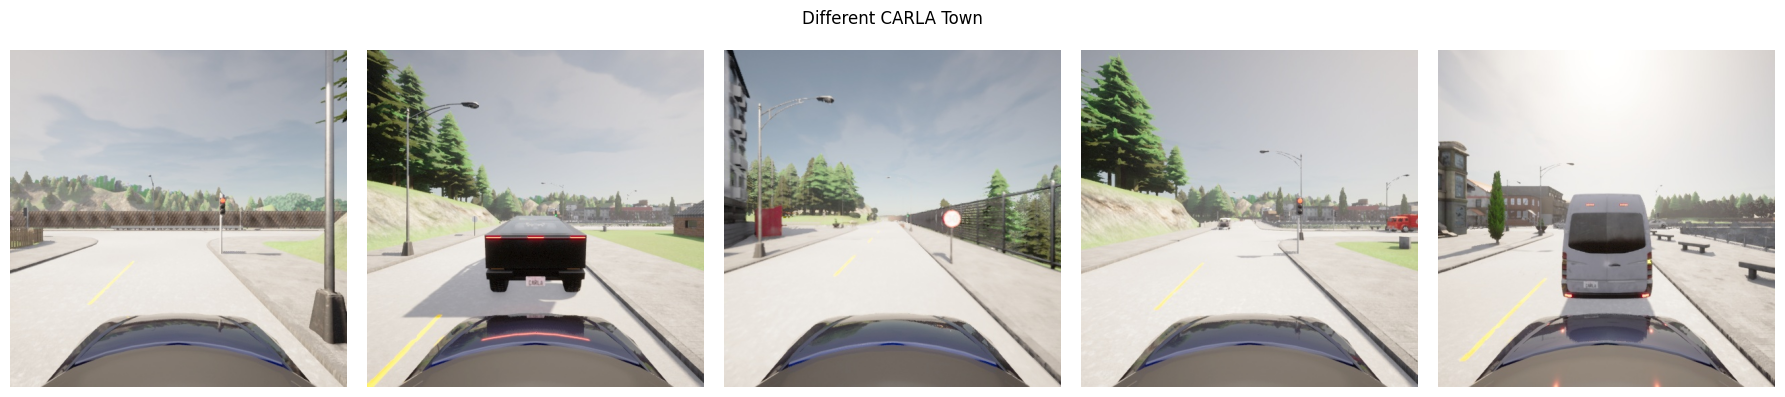

../results/excercise_7\different_town.png


In [12]:
create_town_figure()

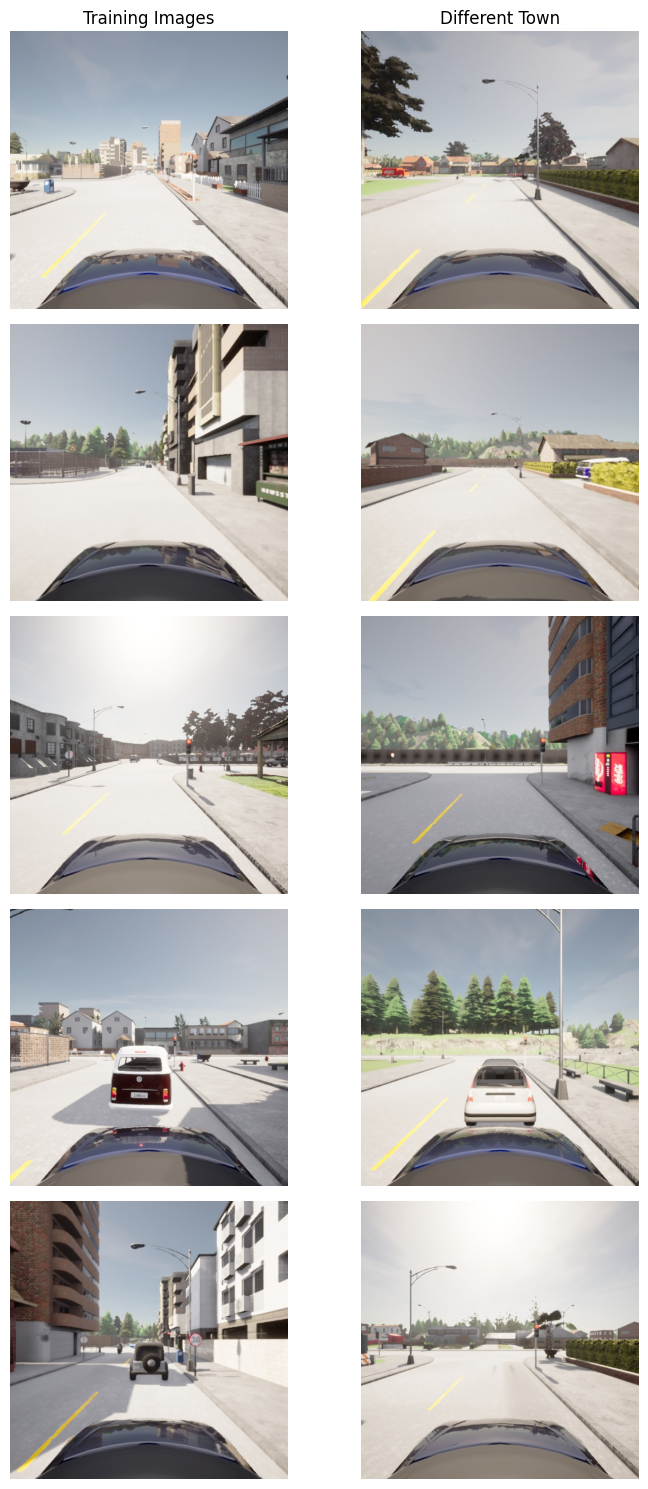

../results/excercise_7\train_vs_town_comparison.png


In [13]:
#Creating comparison images
def create_train_vs_town_comparison():

    TRAIN_DIR = "../datasets/train/rgb-front"

    train_imgs = random.sample(
        sorted(os.listdir(TRAIN_DIR)),
        5
    )

    town_imgs = random.sample(
        sorted(os.listdir(TOWN_DIR)),
        5
    )

    fig, axes = plt.subplots(
        5,
        2,
        figsize=(8, 15)
    )

    for i in range(5):

        train_img = Image.open(
            os.path.join(
                TRAIN_DIR,
                train_imgs[i]
            )
        )

        axes[i, 0].imshow(
            train_img
        )

        axes[i, 0].axis("off")

        town_img = Image.open(
            os.path.join(
                TOWN_DIR,
                town_imgs[i]
            )
        )

        axes[i, 1].imshow(
            town_img
        )

        axes[i, 1].axis("off")

    axes[0, 0].set_title(
        "Training Images"
    )

    axes[0, 1].set_title(
        "Different Town"
    )

    plt.tight_layout()

    output_path = os.path.join(
        RESULTS_DIR,
        "train_vs_town_comparison.png"
    )

    plt.savefig(
        output_path,
        bbox_inches="tight"
    )

    plt.show()

    print(output_path)
create_train_vs_town_comparison()

In [2]:
# confidence is measured as the distance of the predicted probability from 0.5.
# Predictions near 0.5 are uncertain, while predictions near 0.0 or 1.0 are highly confident.

def compute_mean_confidence(

    model,
    dataloader,
    device

):

    model.eval()

    confidences = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(device)

            outputs = model(
                images
            )

            probabilities = torch.sigmoid(
                outputs
            )

            confidence = torch.abs(
                0.5 - probabilities
            )

            confidences.extend(
                confidence.cpu().numpy().flatten()
            )

    return np.mean(
        confidences
    )

In [9]:
#creating dataloaders
batch_size = 32

test_loader = DataLoader(

    ImageOnlyDataset(
        TEST_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

fog_loader = DataLoader(

    ImageOnlyDataset(
        FOG_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

night_loader = DataLoader(

    ImageOnlyDataset(
        NIGHT_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

In [11]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [16]:
def load_model(model_path):

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    return model

pedestrian_model = load_model(
    "../models/pedestrian_model.pth"
)

vehicle_model = load_model(
    "../models/vehicle_model.pth"
)

traffic_model = load_model(
    "../models/traffic_light_model.pth"
)

In [17]:
results = []

models = {

    "Pedestrian":
    pedestrian_model,

    "Vehicle":
    vehicle_model,

    "Traffic Light":
    traffic_model
}

for model_name, model in models.items():

    sunny_confidence = compute_mean_confidence(

        model,

        test_loader,

        device
    )

    fog_confidence = compute_mean_confidence(

        model,

        fog_loader,

        device
    )

    night_confidence = compute_mean_confidence(

        model,

        night_loader,

        device
    )

    results.append({

        "Model":
        model_name,

        "Sunny":
        sunny_confidence,

        "Fog":
        fog_confidence,

        "Night":
        night_confidence
    })

confidence_df = pd.DataFrame(
    results
)

confidence_df

,Model,Sunny,Fog,Night
0,Pedestrian,0.340395,0.450939,0.436260
1,Vehicle,0.421419,0.332196,0.332846
2,Traffic Light,0.486455,0.381870,0.430001


In [18]:
csv_path = os.path.join(

    RESULTS_DIR,

    "exercise9_4_confidence_results.csv"
)

confidence_df.to_csv(

    csv_path,

    index=False
)

print(
    confidence_df
)

print(
    f"\nSaved: {csv_path}"
)

           Model     Sunny       Fog     Night
0     Pedestrian  0.340395  0.450939  0.436260
1        Vehicle  0.421419  0.332196  0.332846
2  Traffic Light  0.486455  0.381870  0.430001

Saved: ../results/excercise_7\exercise9_4_confidence_results.csv


In [19]:
#Excercise 9.6.1 Evaluating MSP Baseline
#pedestrian model has been selected because the results of this model are easily interpretable
TEST_DIR = "../datasets/test/rgb-front"

FOG_DIR = "../datasets/test-fog/rgb-front"

NIGHT_DIR = "../datasets/test-night/rgb-front"

RESULTS_DIR = "../results/excercise_7"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)


In [20]:
class ImageOnlyDataset(Dataset):

    def __init__(

        self,
        image_dir,
        transform

    ):

        self.image_dir = image_dir

        self.transform = transform

        self.images = sorted(
            os.listdir(image_dir)
        )

    def __len__(self):

        return len(
            self.images
        )

    def __getitem__(

        self,
        idx

    ):

        image = Image.open(

            os.path.join(

                self.image_dir,

                self.images[idx]

            )

        ).convert("RGB")

        image = self.transform(
            image
        )

        return image

In [21]:
#Main MSC function
def compute_msp_scores(

    model,
    dataloader,
    device

):

    model.eval()

    scores = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(device)

            outputs = model(
                images
            )

            probs = torch.sigmoid(
                outputs
            )

            msp = torch.maximum(

                probs,

                1 - probs

            )

            scores.extend(

                msp.cpu().numpy().flatten()

            )

    return np.array(
        scores
    )

In [22]:
#Creating data loaders in this cell
batch_size = 32

id_loader = DataLoader(

    ImageOnlyDataset(
        TEST_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

fog_loader = DataLoader(

    ImageOnlyDataset(
        FOG_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

night_loader = DataLoader(

    ImageOnlyDataset(
        NIGHT_DIR,
        transform
    ),

    batch_size=batch_size,

    shuffle=False
)

In [23]:
#Calculating the MSP scores
id_scores = compute_msp_scores(

    pedestrian_model,

    id_loader,

    device
)

fog_scores = compute_msp_scores(

    pedestrian_model,

    fog_loader,

    device
)

night_scores = compute_msp_scores(

    pedestrian_model,

    night_loader,

    device
)

ood_scores = np.concatenate([

    fog_scores,

    night_scores

])

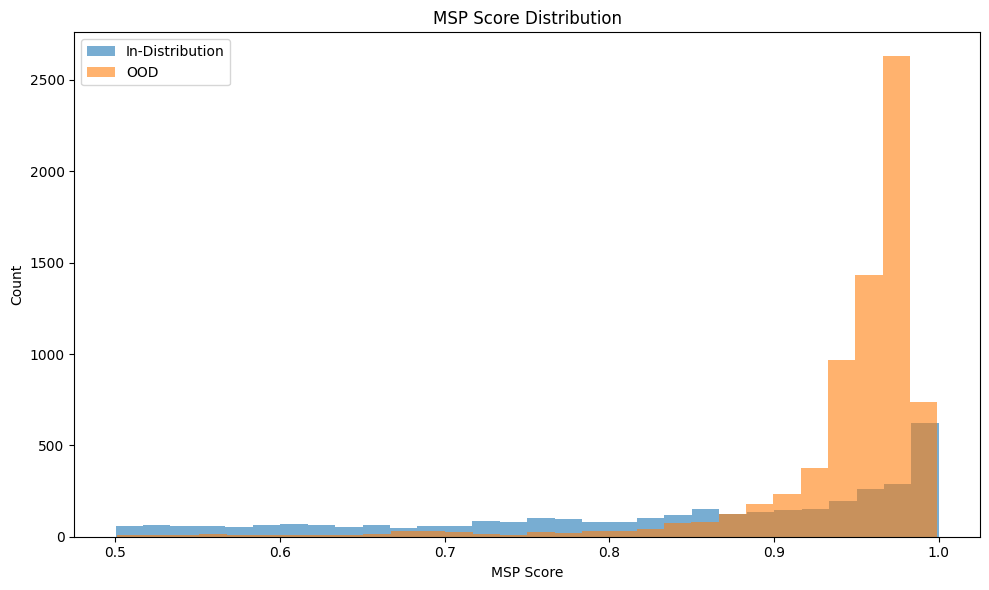

In [24]:
#9.6.1
plt.figure(

    figsize=(10,6)
)

plt.hist(

    id_scores,

    bins=30,

    alpha=0.6,

    label="In-Distribution"
)

plt.hist(

    ood_scores,

    bins=30,

    alpha=0.6,

    label="OOD"
)

plt.xlabel(
    "MSP Score"
)

plt.ylabel(
    "Count"
)

plt.title(
    "MSP Score Distribution"
)

plt.legend()

plt.tight_layout()

plt.savefig(

    f"{RESULTS_DIR}/exercise9_6_msp_distribution.png"

)

plt.show()

In [25]:
#Since high msp = ID and low MSP = OOD, we invert the score as OOD score = 1 - MSP
#AUROC
from sklearn.metrics import roc_auc_score

labels = np.concatenate([

    np.zeros(
        len(id_scores)
    ),

    np.ones(
        len(ood_scores)
    )
])

ood_detection_scores = np.concatenate([

    1 - id_scores,

    1 - ood_scores
])

auroc = roc_auc_score(

    labels,

    ood_detection_scores
)

print(

    f"AUROC = {auroc:.4f}"
)

AUROC = 0.3056


In [26]:
results_df = pd.DataFrame({

    "Metric":

    ["AUROC"],

    "Value":

    [auroc]
})

results_df.to_csv(

    f"{RESULTS_DIR}/exercise9_6_results.csv",

    index=False
)

results_df

,Metric,Value
0,AUROC,0.305648


In [27]:
#Alternate AUROC using raw MSP and not using 1 - MSP
from sklearn.metrics import roc_auc_score

labels = np.concatenate([

    np.zeros(
        len(id_scores)
    ),

    np.ones(
        len(ood_scores)
    )
])

raw_scores = np.concatenate([

    id_scores,

    ood_scores
])

alt_auroc = roc_auc_score(

    labels,

    raw_scores
)

print(
    f"AUROC using raw MSP = {alt_auroc:.4f}"
)

AUROC using raw MSP = 0.6944


In [28]:
#Excercise 9.7 Using the same model as 9.6
# pedestrian model
feature_model = pedestrian_model

feature_extractor = nn.Sequential(

    *list(
        feature_model.children()
    )[:-1]

).to(device)

feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [29]:
#Feature extraction function
def extract_features(

    feature_extractor,
    dataloader,
    device

):

    features = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(device)

            feats = feature_extractor(
                images
            )

            feats = feats.view(

                feats.size(0),

                -1

            )

            features.append(

                feats.cpu().numpy()
            )

    return np.vstack(
        features
    )

In [30]:
#Creating datasets
TRAIN_DIR = "../datasets/train/rgb-front"

train_loader = DataLoader(

    ImageOnlyDataset(
        TRAIN_DIR,
        transform
    ),

    batch_size=32,

    shuffle=False
)

id_loader = DataLoader(

    ImageOnlyDataset(
        TEST_DIR,
        transform
    ),

    batch_size=32,

    shuffle=False
)

fog_loader = DataLoader(

    ImageOnlyDataset(
        FOG_DIR,
        transform
    ),

    batch_size=32,

    shuffle=False
)

night_loader = DataLoader(

    ImageOnlyDataset(
        NIGHT_DIR,
        transform
    ),

    batch_size=32,

    shuffle=False
)

In [31]:
#extracting the features in this cell
train_features = extract_features(

    feature_extractor,

    train_loader,

    device
)

id_features = extract_features(

    feature_extractor,

    id_loader,

    device
)

fog_features = extract_features(

    feature_extractor,

    fog_loader,

    device
)

night_features = extract_features(

    feature_extractor,

    night_loader,

    device
)

In [32]:
#Fit the k-NN detector
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(

    n_neighbors=5
)

knn.fit(
    train_features
)

NearestNeighbors()

In [33]:
#Computing OOD scores - (larger distance → more OOD)
def knn_scores(

    knn,
    features

):

    distances, _ = knn.kneighbors(
        features
    )

    return distances.mean(
        axis=1
    )


In [34]:
id_scores = knn_scores(

    knn,

    id_features
)

fog_scores = knn_scores(

    knn,

    fog_features
)

night_scores = knn_scores(

    knn,

    night_features
)

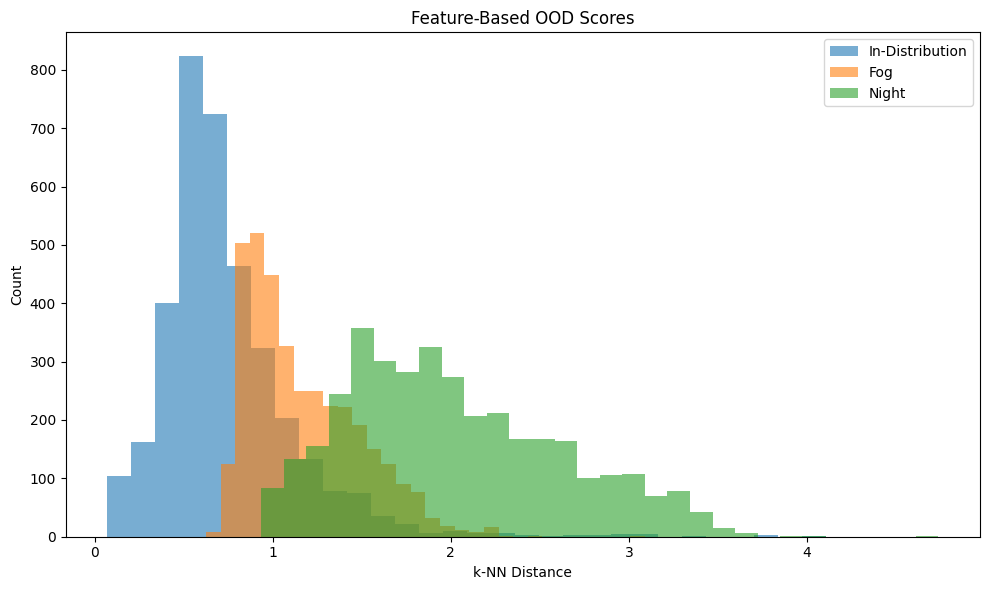

In [35]:
#Plotting the distribution
plt.figure(

    figsize=(10,6)
)

plt.hist(

    id_scores,

    bins=30,

    alpha=0.6,

    label="In-Distribution"
)

plt.hist(

    fog_scores,

    bins=30,

    alpha=0.6,

    label="Fog"
)

plt.hist(

    night_scores,

    bins=30,

    alpha=0.6,

    label="Night"
)

plt.xlabel(
    "k-NN Distance"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Feature-Based OOD Scores"
)

plt.legend()

plt.tight_layout()

plt.savefig(

    "../results/excercise_7/exercise9_7_knn_distribution.png"
)

plt.show()

In [36]:
#AUROC combined for all OOD
from sklearn.metrics import roc_auc_score

ood_scores = np.concatenate([

    fog_scores,

    night_scores
])

labels = np.concatenate([

    np.zeros(
        len(id_scores)
    ),

    np.ones(
        len(ood_scores)
    )
])

scores = np.concatenate([

    id_scores,

    ood_scores
])

knn_auroc = roc_auc_score(

    labels,

    scores
)

print(
    f"k-NN AUROC = {knn_auroc:.4f}"
)

k-NN AUROC = 0.9124


In [37]:
#Finding the OOD scenario for which the gap is the largest
fog_labels = np.concatenate([

    np.zeros(
        len(id_scores)
    ),

    np.ones(
        len(fog_scores)
    )
])

fog_auroc = roc_auc_score(

    fog_labels,

    np.concatenate([

        id_scores,

        fog_scores
    ])
)

night_labels = np.concatenate([

    np.zeros(
        len(id_scores)
    ),

    np.ones(
        len(night_scores)
    )
])

night_auroc = roc_auc_score(

    night_labels,

    np.concatenate([

        id_scores,

        night_scores
    ])
)

print(
    f"Fog AUROC   = {fog_auroc:.4f}"
)

print(
    f"Night AUROC = {night_auroc:.4f}"
)

Fog AUROC   = 0.8518
Night AUROC = 0.9729


In [38]:
#Comparig the computed AUROC wuth MSP AUROC from Excercise 9.6
MSP_AUROC = 0.3056
comparison_df = pd.DataFrame({

    "Detector":[

        "MSP",

        "k-NN"
    ],

    "AUROC":[

        MSP_AUROC,

        knn_auroc
    ]
})

comparison_df

,Detector,AUROC
0,MSP,0.305600
1,k-NN,0.912373


In [39]:
results_df = pd.DataFrame({

    "Metric":[

        "MSP_AUROC",

        "KNN_AUROC",

        "Fog_AUROC",

        "Night_AUROC"
    ],

    "Value":[

        MSP_AUROC,

        knn_auroc,

        fog_auroc,

        night_auroc
    ]
})

results_df.to_csv(

    "../results/excercise_7/exercise9_7_results.csv",

    index=False
)

results_df

,Metric,Value
0,MSP_AUROC,0.305600
1,KNN_AUROC,0.912373
2,Fog_AUROC,0.851843
3,Night_AUROC,0.972904
